# Analyze W&B Training Runs

Fetch and visualize training metrics from W&B for any round of hyperparameter search.

**Sections:**

1. Configuration (W&B project, entity, group)
2. Run summary table
3. Loss curves (eval + train)
4. mAP curves (mAP@50:95, mAP@50)
5. Learning rate schedules
6. Ranking (best mAP bar chart)
7. Analysis & recommendations

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moku.runs import fetch_wandb_histories, fetch_wandb_runs

## Configuration

In [2]:
GROUP = "r4"  # Change to analyze a different round

runs_df = fetch_wandb_runs(group=GROUP)
print(f"Found {len(runs_df)} runs in group '{GROUP}'")

# Summary table: key metrics
cols = ["name", "state", "eval/map", "eval/map_50", "eval/map_75", "eval/mar_400", "eval/loss"]
display(runs_df[cols].sort_values("eval/map", ascending=False).reset_index(drop=True))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Found 10 runs in group 'r4'


,name,state,eval/map,eval/map_50,eval/map_75,eval/mar_400,eval/loss
0,r4_lr5e-4_cos200,finished,0.549236,0.844548,0.678304,0.712330,5.402751
1,r4_lr1e-3_linear200,finished,0.517981,0.776053,0.666925,0.685859,5.219999
2,r4_lr1e-3_cos200,finished,0.513746,0.738950,0.664333,0.678967,5.344576
3,r4_lr1e-3_cos200_wd1e-3,finished,0.500364,0.730056,0.646737,0.670595,5.206141
4,r4_lr1e-3_cosrestart300_wd1e-3,finished,0.480068,0.727493,0.620514,0.682469,4.903395
5,r4_lr1e-3_cos200_wd5e-3,finished,0.478976,0.690237,0.618753,0.554123,5.295061
6,r4_lr1e-3_cosminlr200,finished,0.477996,0.693558,0.636989,0.667634,5.176549
7,r4_lr1.5e-3_linear200_wd1e-3,finished,0.471687,0.693906,0.614650,0.666821,5.427189
8,r4_lr1e-3_cosrestart200,finished,0.456965,0.686381,0.581486,0.664713,5.246276
9,r4_lr2e-3_cos200,finished,0.066706,0.110297,0.077899,0.250683,7.191113


## Fetch Training History

In [6]:
history = fetch_wandb_histories(group=GROUP)

# Add epoch column from train/epoch (forward-fill within each run)
history = history.sort_values(["run", "_step"])
history["epoch"] = history.groupby("run")["train/epoch"].ffill()
print(f"Loaded {len(history)} history rows across {history['run'].nunique()} runs")

Loaded 11350 history rows across 10 runs


## Eval Loss Curves

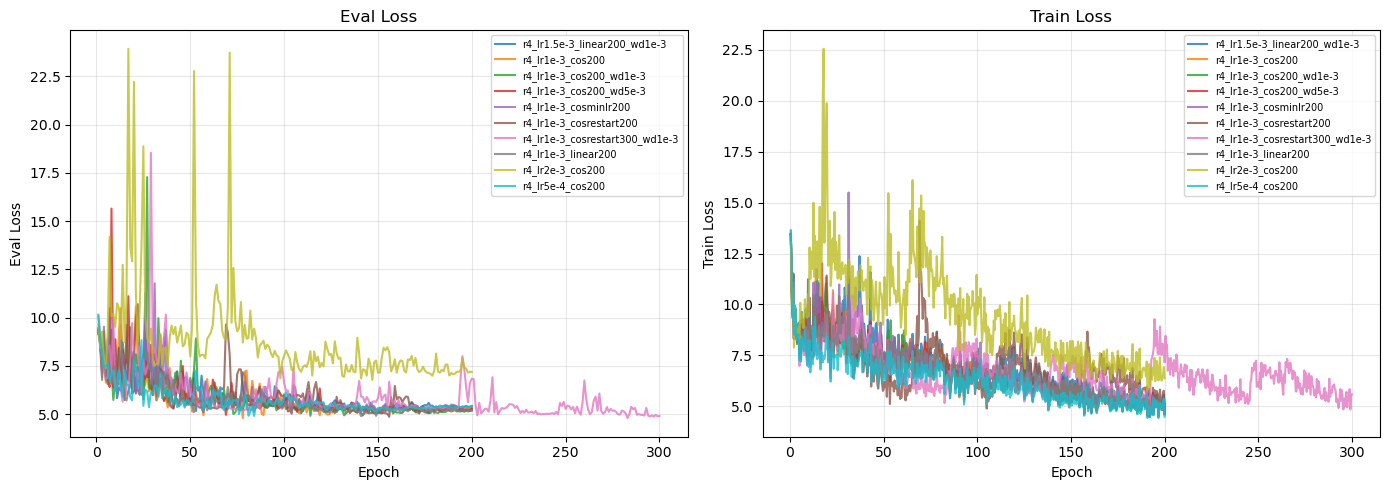

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_name, group in history.groupby("run"):
    eval_data = group.dropna(subset=["eval/loss"])
    if not eval_data.empty:
        axes[0].plot(eval_data["epoch"], eval_data["eval/loss"], label=run_name, alpha=0.8)

    train_data = group.dropna(subset=["train/loss"])
    if not train_data.empty:
        axes[1].plot(train_data["epoch"], train_data["train/loss"], label=run_name, alpha=0.8)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Eval Loss")
axes[0].set_title("Eval Loss")
axes[0].legend(fontsize=7, loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Train Loss")
axes[1].set_title("Train Loss")
axes[1].legend(fontsize=7, loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## mAP Curves

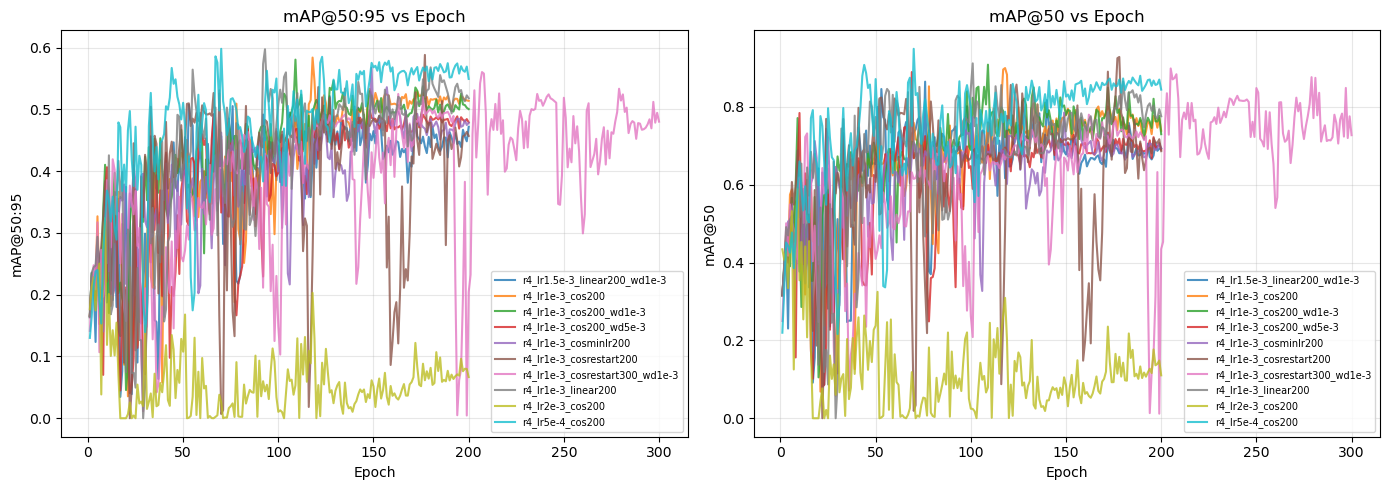

In [9]:
# Use train/eval/map* columns (logged by MAPEvalCallback during training)
# The eval/map* columns only appear at the very end from Trainer final eval
map_col = "train/eval/map" if "train/eval/map" in history.columns else "eval/map"
map50_col = "train/eval/map_50" if "train/eval/map_50" in history.columns else "eval/map_50"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_name, group in history.groupby("run"):
    map_data = group.dropna(subset=[map_col])
    if not map_data.empty:
        axes[0].plot(map_data["epoch"], map_data[map_col], label=run_name, alpha=0.8)

    map50_data = group.dropna(subset=[map50_col])
    if not map50_data.empty:
        axes[1].plot(map50_data["epoch"], map50_data[map50_col], label=run_name, alpha=0.8)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP@50:95")
axes[0].set_title("mAP@50:95 vs Epoch")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@50")
axes[1].set_title("mAP@50 vs Epoch")
axes[1].legend(fontsize=7, loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Learning Rate Schedules

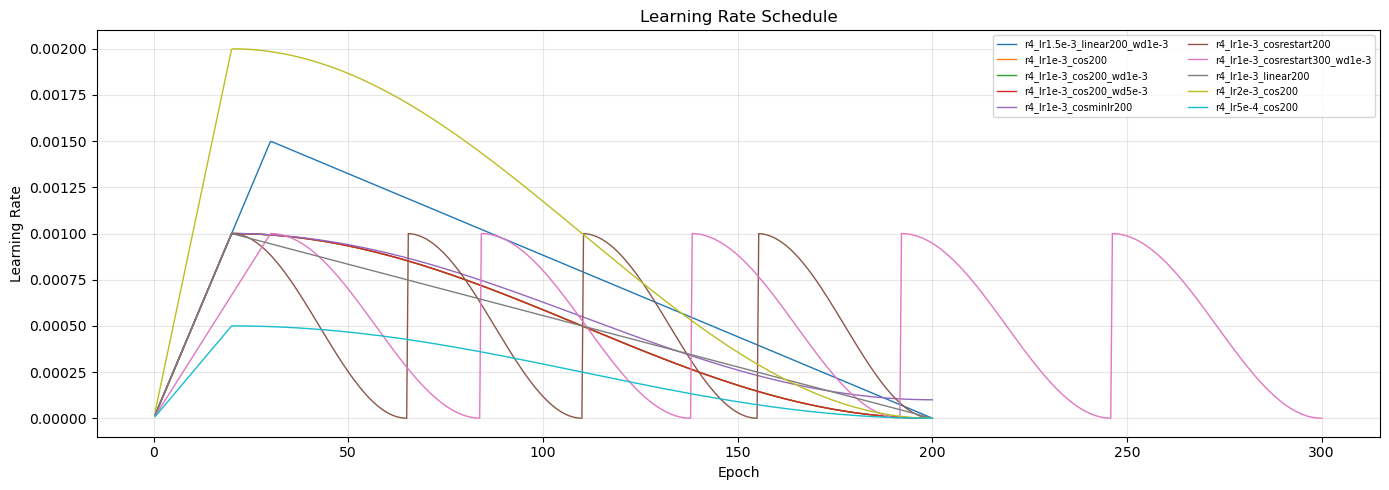

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

for run_name, group in history.groupby("run"):
    rd = group.dropna(subset=["train/learning_rate"])
    if rd.empty:
        continue
    ax.plot(rd["epoch"], rd["train/learning_rate"], label=run_name, linewidth=1)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Run Ranking

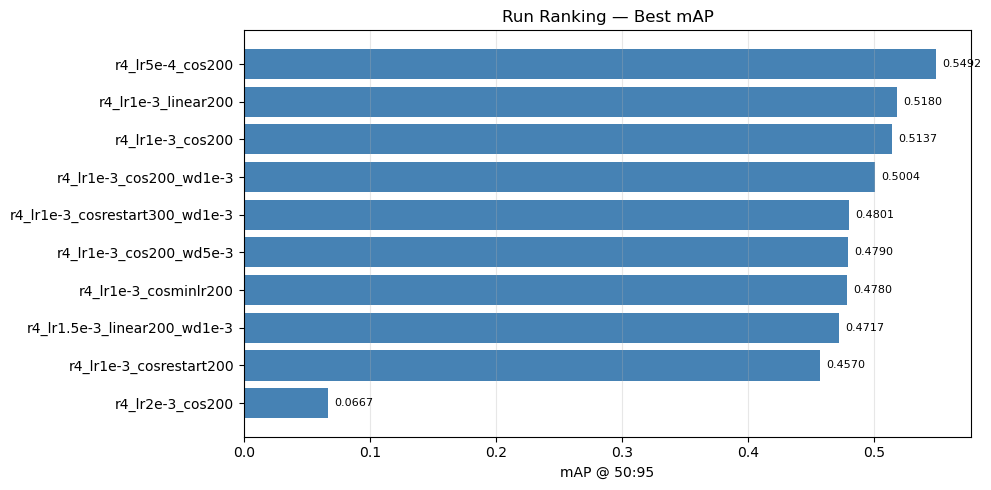

In [11]:
# Best mAP per run (from W&B summary)
ranking = runs_df[["name", "eval/map", "eval/map_50", "eval/map_75"]].copy()
ranking = ranking.sort_values("eval/map", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(ranking) * 0.5)))
bars = ax.barh(ranking["name"], ranking["eval/map"], color="steelblue")
ax.set_xlabel("mAP @ 50:95")
ax.set_title("Run Ranking — Best mAP")
ax.grid(True, axis="x", alpha=0.3)

# Annotate bars
for bar, val in zip(bars, ranking["eval/map"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Best Epoch Per Run

In [ ]:
# Find epoch with highest mAP for each run (using train/eval/map from MAPEvalCallback)
map_col = "train/eval/map" if "train/eval/map" in history.columns else "eval/map"
map50_col = "train/eval/map_50" if "train/eval/map_50" in history.columns else "eval/map_50"
map75_col = "train/eval/map_75" if "train/eval/map_75" in history.columns else "eval/map_75"
mar400_col = "train/eval/mar_400" if "train/eval/mar_400" in history.columns else "eval/mar_400"

eval_hist = history.dropna(subset=[map_col])

best_rows = []
for run_name, group in eval_hist.groupby("run"):
    best_idx = group[map_col].idxmax()
    row = group.loc[best_idx]
    best_rows.append({
        "run": run_name,
        "best_epoch": int(row["epoch"]) if pd.notna(row["epoch"]) else "?",
        "mAP": row[map_col],
        "mAP_50": row.get(map50_col, float("nan")),
        "mAP_75": row.get(map75_col, float("nan")),
        "mAR_400": row.get(mar400_col, float("nan")),
    })

best_df = pd.DataFrame(best_rows).sort_values("mAP", ascending=False).reset_index(drop=True)
display(best_df)

                           run  best_epoch    mAP  mAP_50  mAP_75  mAR_400
              r4_lr5e-4_cos200          70 0.5980  0.9494  0.7069   0.7028
           r4_lr1e-3_linear200          93 0.5972  0.8288  0.8006   0.6937
       r4_lr1e-3_cosrestart200         177 0.5881  0.9253  0.7248   0.6853
              r4_lr1e-3_cos200         118 0.5838  0.8999  0.7483   0.6850
       r4_lr1e-3_cos200_wd1e-3         109 0.5804  0.9087  0.7023   0.6893
         r4_lr1e-3_cosminlr200         149 0.5671  0.7855  0.7353   0.6698
r4_lr1e-3_cosrestart300_wd1e-3         207 0.5603  0.8743  0.6642   0.6605
       r4_lr1e-3_cos200_wd5e-3          69 0.5256  0.8896  0.6640   0.6233
  r4_lr1.5e-3_linear200_wd1e-3         127 0.5212  0.8114  0.5886   0.6555
              r4_lr2e-3_cos200           9 0.3241  0.5890  0.2980   0.4236


## Analysis & Recommendations

_Fill in after reviewing results above._